In [86]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [87]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [112]:
df_train

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,37,70,36,1,8,36,4,5,4
1,27,69,65,4,4,30,6,18,4
2,29,63,32,4,4,24,12,16,2
3,35,62,54,4,0,39,12,4,0
4,35,58,43,3,6,37,2,16,5
...,...,...,...,...,...,...,...,...,...
749995,25,69,30,1,3,8,16,6,4
749996,37,64,58,2,8,38,8,20,2
749997,35,68,59,4,2,6,11,29,0
749998,31,68,29,3,1,9,11,12,3


In [113]:
df_test

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous
0,31,70,52,4,10,34,11,24
1,27,62,45,3,8,30,14,15
2,28,72,28,1,2,14,15,4
3,37,53,57,0,2,18,17,36
4,31,55,32,3,7,13,19,14
...,...,...,...,...,...,...,...,...
249995,26,66,30,3,8,14,7,18
249996,33,62,55,3,7,28,14,7
249997,36,53,64,0,6,28,11,27
249998,36,67,26,1,6,33,0,10


In [90]:
df_train['Fertilizer Name'].value_counts()

Fertilizer Name
14-35-14    114436
10-26-26    113887
17-17-17    112453
28-28       111158
20-20       110889
DAP          94860
Urea         92317
Name: count, dtype: int64

In [91]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   id               750000 non-null  int64 
 1   Temparature      750000 non-null  int64 
 2   Humidity         750000 non-null  int64 
 3   Moisture         750000 non-null  int64 
 4   Soil Type        750000 non-null  object
 5   Crop Type        750000 non-null  object
 6   Nitrogen         750000 non-null  int64 
 7   Potassium        750000 non-null  int64 
 8   Phosphorous      750000 non-null  int64 
 9   Fertilizer Name  750000 non-null  object
dtypes: int64(7), object(3)
memory usage: 57.2+ MB


In [92]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           250000 non-null  int64 
 1   Temparature  250000 non-null  int64 
 2   Humidity     250000 non-null  int64 
 3   Moisture     250000 non-null  int64 
 4   Soil Type    250000 non-null  object
 5   Crop Type    250000 non-null  object
 6   Nitrogen     250000 non-null  int64 
 7   Potassium    250000 non-null  int64 
 8   Phosphorous  250000 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 17.2+ MB


In [93]:
df_train.isna().sum()

id                 0
Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

In [94]:
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

In [95]:
from sklearn.preprocessing import LabelEncoder

In [96]:
label = LabelEncoder()

In [97]:
df_train['Soil Type'].value_counts()

Soil Type
Sandy     156710
Black     150956
Clayey    148382
Red       148102
Loamy     145850
Name: count, dtype: int64

In [98]:
df_train['Crop Type'].value_counts()

Crop Type
Paddy          85754
Pulses         78180
Cotton         69171
Tobacco        68000
Wheat          66628
Millets        65291
Barley         65045
Sugarcane      64269
Oil seeds      64184
Maize          62569
Ground Nuts    60909
Name: count, dtype: int64

In [99]:
df_train['Soil Type'] = label.fit_transform(df_train['Soil Type'])
df_test['Soil Type'] = label.transform(df_test['Soil Type'])
df_train['Crop Type'] = label.fit_transform(df_train['Crop Type'])
df_test['Crop Type'] = label.transform(df_test['Crop Type'])

In [100]:
df_train['Fertilizer Name'] = label.fit_transform(df_train['Fertilizer Name'])

In [101]:
X_train = df_train.drop('Fertilizer Name', axis=1)
y_train = df_train['Fertilizer Name']
X_test = df_test.copy()

In [102]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [103]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [104]:
from keras.utils import to_categorical

In [105]:
y_train = to_categorical(y_train,num_classes=7)

In [106]:
y_train.shape

(750000, 7)

In [107]:
from keras import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [108]:
X_train.shape

(750000, 8)

In [109]:
model = Sequential()
model.add(Dense(units=16, activation='relu', input_shape=(8, )))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=7, activation='softmax'))

C:\Users\USER\Desktop\ML jupyter\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [110]:
model.compile(optimizer = Adam(learning_rate = 0.001),loss = 'categorical_crossentropy', metrics=['accuracy'])

In [111]:
model.fit(X_train,y_train, validation_split = 0.30, epochs = 15)

Epoch 1/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 66s 4ms/step - accuracy: 0.1520 - loss: 1.9428 - val_accuracy: 0.1526 - val_loss: 1.9425
Epoch 2/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 83s 4ms/step - accuracy: 0.1533 - loss: 1.9423 - val_accuracy: 0.1541 - val_loss: 1.9424
Epoch 3/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 82s 4ms/step - accuracy: 0.1533 - loss: 1.9422 - val_accuracy: 0.1547 - val_loss: 1.9421
Epoch 4/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 67s 4ms/step - accuracy: 0.1553 - loss: 1.9419 - val_accuracy: 0.1544 - val_loss: 1.9420
Epoch 5/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 81s 4ms/step - accuracy: 0.1552 - loss: 1.9418 - val_accuracy: 0.1532 - val_loss: 1.9422
Epoch 6/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 82s 4ms/step - accuracy: 0.1556 - loss: 1.9418 - val_accuracy: 0.1542 - val_loss: 1.9420
Epoch 7/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 82s 4ms/step - accuracy: 0.1556 - loss: 1.9417 - val_accuracy: 0.1531 - val_loss: 1.9419
Epoch 8/15
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 82s 4ms/step - accuracy: 

In [114]:
y_pred = model.predict(X_test)

7813/7813 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step


In [115]:
y_pred

array([[0.15356754, 0.14534716, 0.14446093, ..., 0.13733785, 0.14155203,
        0.12759504],
       [0.16950658, 0.16338031, 0.16750093, ..., 0.14013161, 0.09861112,
        0.09442712],
       [0.15983294, 0.15495506, 0.15368694, ..., 0.14437181, 0.11806884,
        0.11261246],
       ...,
       [0.15336365, 0.15315843, 0.14585249, ..., 0.15507728, 0.12126211,
        0.12148514],
       [0.15290442, 0.14975993, 0.14856368, ..., 0.14795037, 0.12849669,
        0.12307371],
       [0.1561778 , 0.15276857, 0.14975931, ..., 0.14857844, 0.12117533,
        0.11847588]], shape=(250000, 7), dtype=float32)

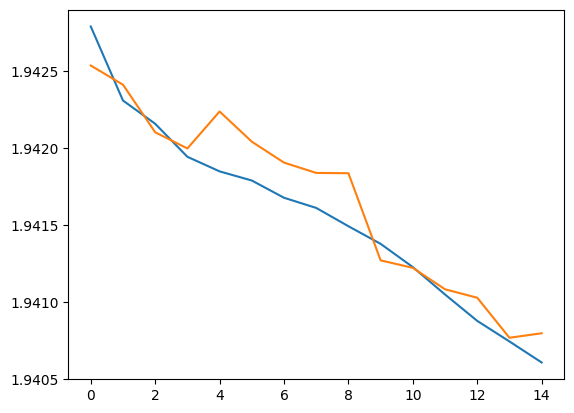

In [116]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [117]:
df_sub = pd.read_csv('sample_submission.csv')

In [118]:
df_sub['Fertilizer Name'] = y_pred

In [119]:
df_sub.to_csv('sub6.csv',index = False, index_label= False)